Hedef Değişken (Class) Hariç Toplam Öznitelik Sayısı: 13
Öznitelikler: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'plate', 'u_g_index', 'g_r_index', 'r_i_index', 'i_z_index']


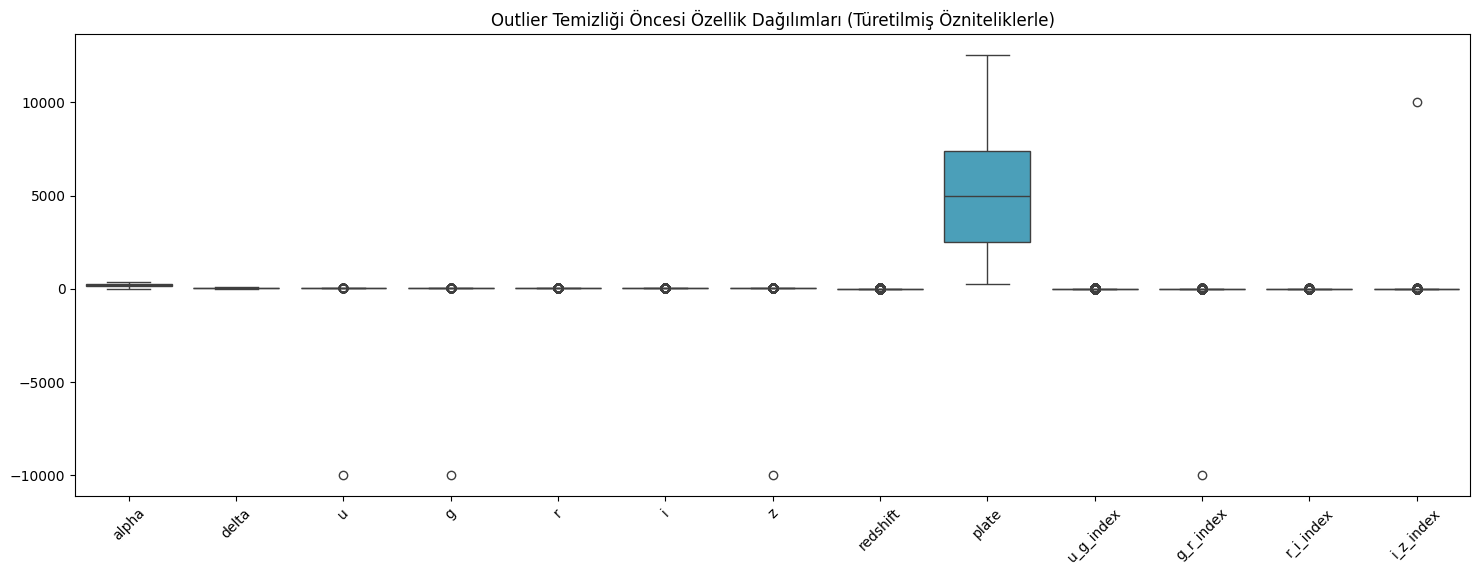


Orijinal veri boyutu: 100000 satır
Temizlenmiş veri boyutu: 82339 satır


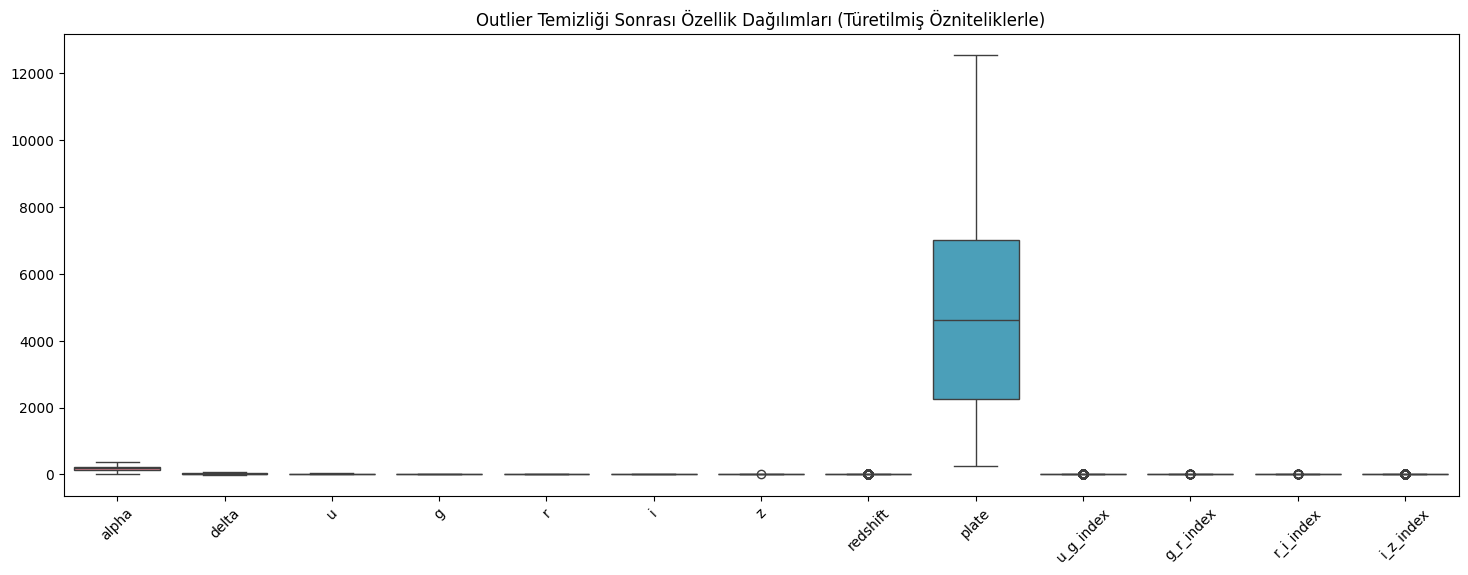

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme
df = pd.read_csv('star.csv')

# İşe yaramayan, modelin genellenebilirliğini bozan ID ve metadata kolonlarını düşüyoruz
drop_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'MJD']
df_cleaned = df.drop(columns=drop_cols)

# --- FEATURE ENGINEERING (ÖZNİTELİK MÜHENDİSLİĞİ) ADIMI ---
# Astronomik renk indekslerinin türetilmesi
df_cleaned['u_g_index'] = df_cleaned['u'] - df_cleaned['g']
df_cleaned['g_r_index'] = df_cleaned['g'] - df_cleaned['r']
df_cleaned['r_i_index'] = df_cleaned['r'] - df_cleaned['i']
df_cleaned['i_z_index'] = df_cleaned['i'] - df_cleaned['z']

# Sadece sayısal özellikleri (features) seçiyoruz ('class' hariç)
num_cols = df_cleaned.drop(columns=['class']).columns

print(f"Hedef Değişken (Class) Hariç Toplam Öznitelik Sayısı: {len(num_cols)}")
print(f"Öznitelikler: {list(num_cols)}")

# 2. Temizlik Öncesi Boxplot Çizimi
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_cleaned[num_cols])
plt.title('Outlier Temizliği Öncesi Özellik Dağılımları (Türetilmiş Özniteliklerle)')
plt.xticks(rotation=45)
plt.show()

# 3. IQR Yöntemi ile Outlier Tespiti ve Temizliği
def remove_outliers_iqr(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Yalnızca alt ve üst sınırlar içinde kalan verileri tutuyoruz
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

df_no_outliers = remove_outliers_iqr(df_cleaned, num_cols)

print(f"\nOrijinal veri boyutu: {df_cleaned.shape[0]} satır")
print(f"Temizlenmiş veri boyutu: {df_no_outliers.shape[0]} satır")

# 4. Temizlik Sonrası Boxplot Çizimi
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_no_outliers[num_cols])
plt.title('Outlier Temizliği Sonrası Özellik Dağılımları (Türetilmiş Özniteliklerle)')
plt.xticks(rotation=45)
plt.show()

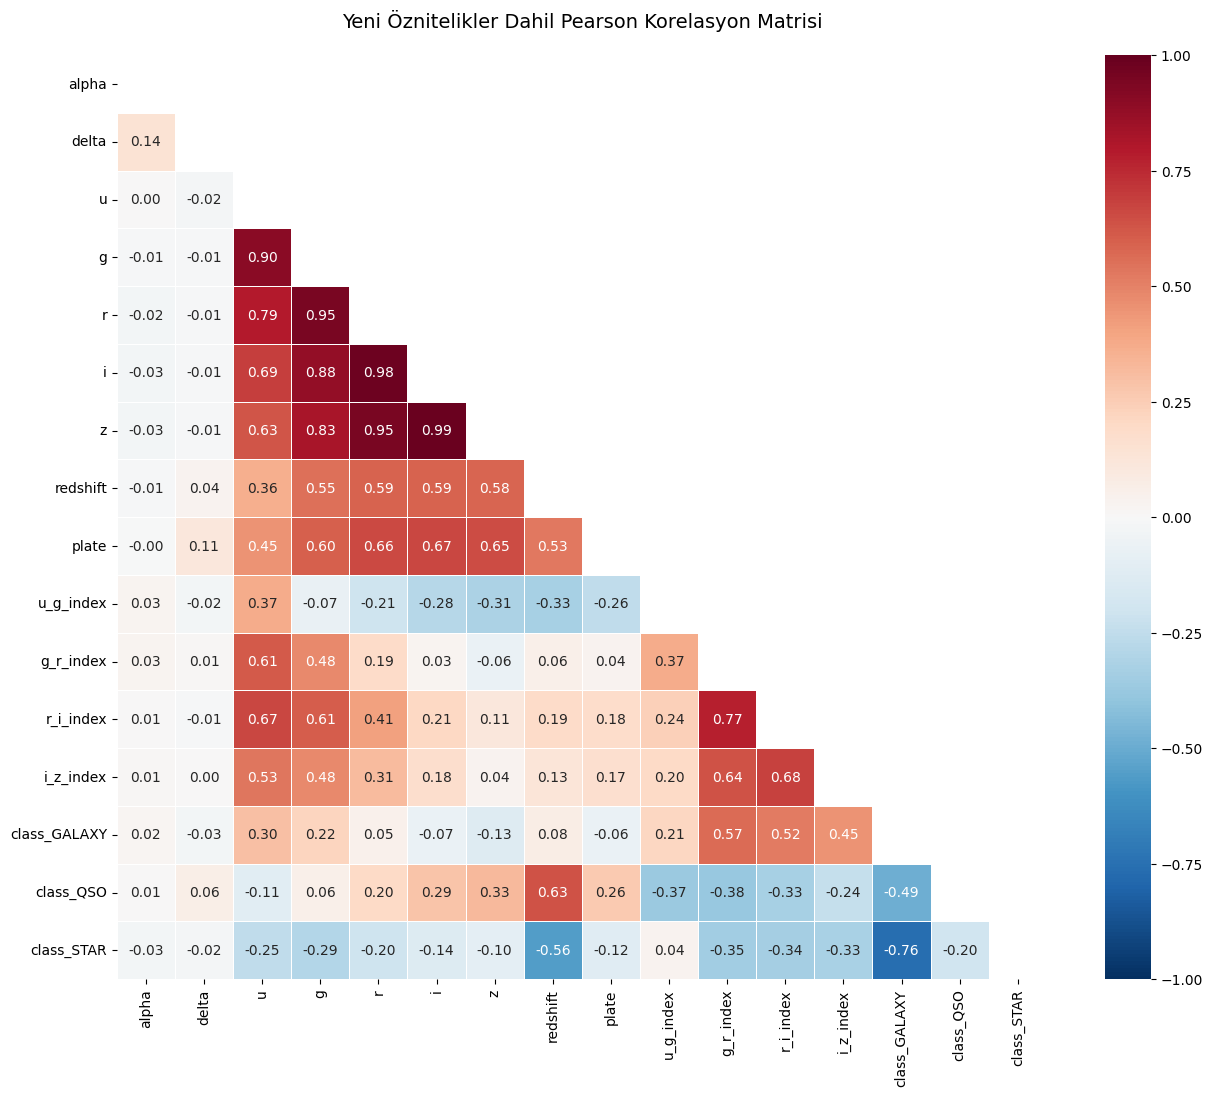

--- Öznitelikler Arasındaki En Güçlü Pozitif Korelasyonlar (r > 0.70) ---
z          i            0.990277
r          i            0.976789
g          r            0.952381
z          r            0.947230
g          u            0.899028
i          g            0.879565
g          z            0.825376
r          u            0.794321
r_i_index  g_r_index    0.773672
dtype: float64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sınıf etiketlerini sayısallaştırma (One-Hot Encoding)
df_encoded = pd.get_dummies(df_no_outliers, columns=['class'], prefix='class', dtype=int)

# 2. Pearson Korelasyon Matrisi
corr_matrix = df_encoded.corr()

# 3. Görselleştirme
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap="RdBu_r", 
            vmin=-1, vmax=1, 
            linewidths=0.5)

plt.title('Yeni Öznitelikler Dahil Pearson Korelasyon Matrisi', fontsize=14, pad=20)
plt.show()

# En yüksek korelasyonları listeleme
print("--- Öznitelikler Arasındaki En Güçlü Pozitif Korelasyonlar (r > 0.70) ---")
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.70)].drop_duplicates()
print(high_corr)

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Z-Score Standardizasyonu
X_features = df_no_outliers.drop(columns=['class'])
y_target = df_no_outliers['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# DataFrame formatına geri getirme
df_scaled = pd.DataFrame(X_scaled, columns=X_features.columns)
df_scaled['class'] = y_target.values

# 2. Fisher Uzaklığı Hesaplama Fonksiyonu
def calculate_pairwise_fisher(df, feature_columns, class_column):
    unique_classes = df[class_column].unique()
    fisher_records = []
    
    for col in feature_columns:
        record = {'Öznitelik (Feature)': col}
        for i in range(len(unique_classes)):
            for j in range(i + 1, len(unique_classes)):
                c1, c2 = unique_classes[i], unique_classes[j]
                data_c1 = df[df[class_column] == c1][col]
                data_c2 = df[df[class_column] == c2][col]
                
                m1, v1 = data_c1.mean(), data_c1.var()
                m2, v2 = data_c2.mean(), data_c2.var()
                
                denominator = v1 + v2
                record[f'{c1} vs {c2}'] = ((m1 - m2) ** 2) / denominator if denominator != 0 else 0
        fisher_records.append(record)
    return pd.DataFrame(fisher_records)

# Fisher Uzaklıklarını Hesaplama
fisher_df = calculate_pairwise_fisher(df_scaled, X_features.columns, 'class')
print("--- 12 Özniteliğin Sınıflar Arası Fisher Uzaklıkları ---")
print(fisher_df.sort_values(by=fisher_df.columns[1], ascending=False).to_string(index=False))

--- 12 Özniteliğin Sınıflar Arası Fisher Uzaklıkları ---
Öznitelik (Feature)  GALAXY vs QSO  GALAXY vs STAR  QSO vs STAR
          g_r_index       2.033904        0.802574     0.197139
           redshift       1.984120        2.515758     7.312238
          r_i_index       1.505956        0.588597     0.070651
          u_g_index       1.038634        0.004765     1.226904
                  z       0.770513        0.002830     0.763429
          i_z_index       0.561321        0.479742     0.002754
                  i       0.543818        0.019960     0.731787
              plate       0.295255        0.017361     0.470920
                  u       0.204853        0.232747     0.014629
                  r       0.190295        0.080947     0.603530
              delta       0.019560        0.000107     0.021334
              alpha       0.000013        0.002087     0.002274
                  g       0.000002        0.243813     0.370850


--- Temel Bileşenlerin Özdeğerleri ve Fisher Uzaklıkları ---
Öznitelik (Feature)  Özdeğer (Eigenvalue)  GALAXY vs QSO  GALAXY vs STAR  QSO vs STAR
                PC1          5.803487e+00       0.055763        0.274633     0.821707
                PC2          2.749600e+00       3.860128        0.338934     1.193587
                PC3          1.158841e+00       0.025209        0.012118     0.067941
                PC4          9.084526e-01       0.032926        0.186190     0.381107
                PC5          8.410833e-01       0.011210        0.137504     0.241722
                PC6          5.156224e-01       0.632533        0.447676     1.565909
                PC7          4.614779e-01       0.028717        0.104074     0.181902
                PC8          3.548625e-01       0.181357        0.026872     0.323517
                PC9          2.067314e-01       0.013217        0.013637     0.059896
               PC10          1.201769e-15       1.399767        0.161398     0.

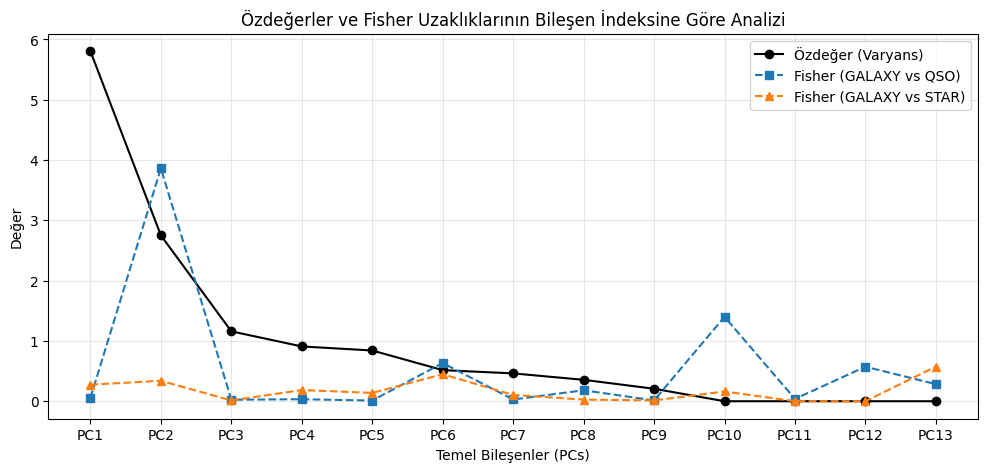

In [4]:
from sklearn.decomposition import PCA

# 1. PCA Fit
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pc_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_columns)
df_pca['class'] = y_target.values
eigenvalues = pca.explained_variance_

# 2. Bileşenler İçin Fisher Hesaplama
fisher_pc_df = calculate_pairwise_fisher(df_pca, pc_columns, 'class')
# Özdeğerleri tabloya ekleyelim
fisher_pc_df.insert(1, 'Özdeğer (Eigenvalue)', eigenvalues)

print("--- Temel Bileşenlerin Özdeğerleri ve Fisher Uzaklıkları ---")
print(fisher_pc_df.to_string(index=False))

# 3. Grafik Çizimi
plt.figure(figsize=(12, 5))
plt.plot(fisher_pc_df['Öznitelik (Feature)'], fisher_pc_df['Özdeğer (Eigenvalue)'], marker='o', label='Özdeğer (Varyans)', color='black')
plt.plot(fisher_pc_df['Öznitelik (Feature)'], fisher_pc_df.iloc[:, 2], marker='s', label=f'Fisher ({fisher_pc_df.columns[2]})', linestyle='--')
plt.plot(fisher_pc_df['Öznitelik (Feature)'], fisher_pc_df.iloc[:, 3], marker='^', label=f'Fisher ({fisher_pc_df.columns[3]})', linestyle='--')
plt.title('Özdeğerler ve Fisher Uzaklıklarının Bileşen İndeksine Göre Analizi')
plt.xlabel('Temel Bileşenler (PCs)')
plt.ylabel('Değer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

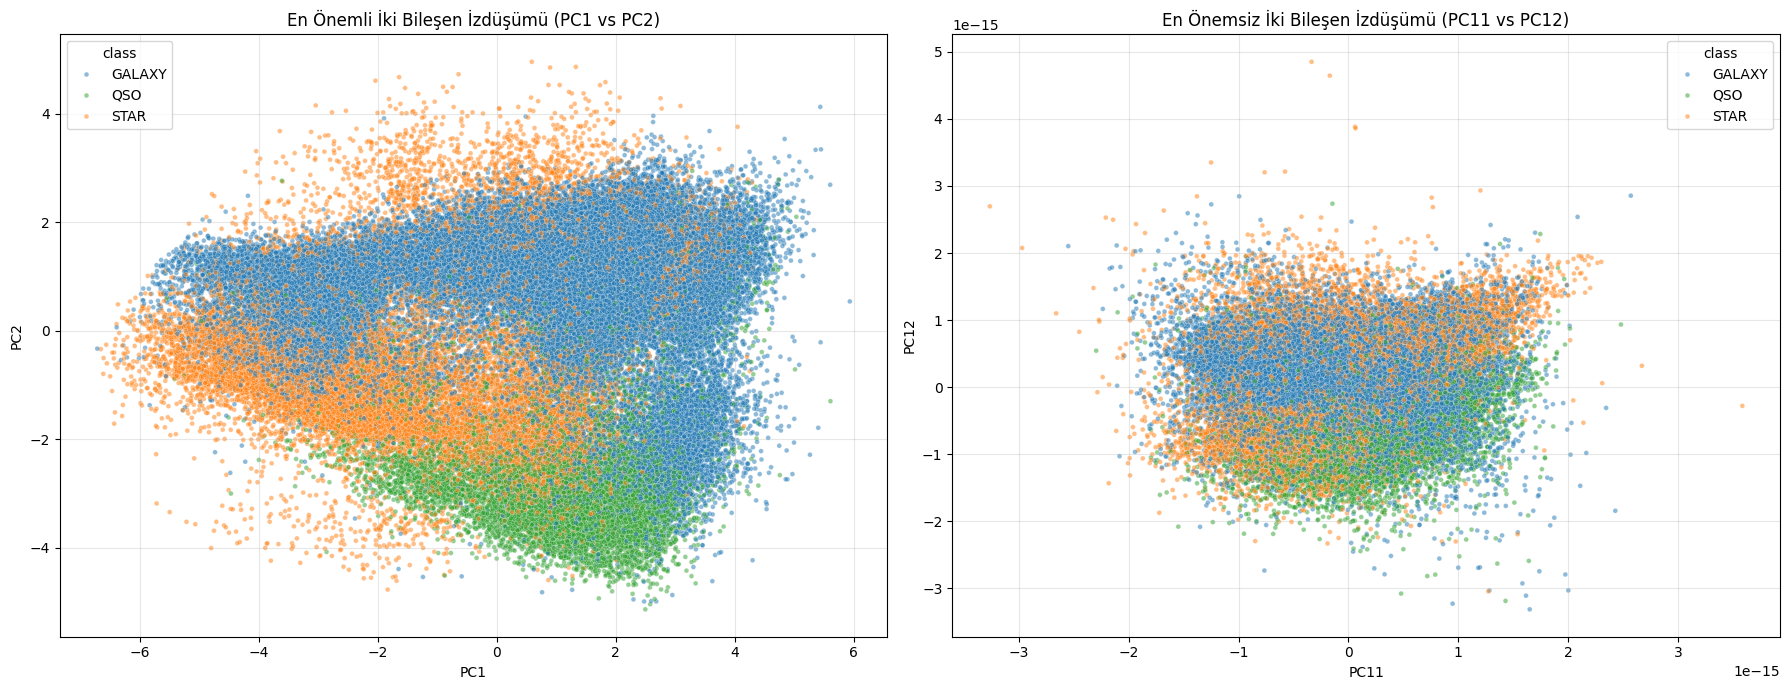

In [5]:
# Renk paleti ayarı
class_palette = {'GALAXY': '#1f77b4', 'STAR': '#ff7f0e', 'QSO': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2 (En Önemli)
sns.scatterplot(ax=axes[0], x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['class'], palette=class_palette, alpha=0.5, s=12)
axes[0].set_title('En Önemli İki Bileşen İzdüşümü (PC1 vs PC2)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# PC11 vs PC12 (En Önemsiz - Son iki bileşen)
sns.scatterplot(ax=axes[1], x=df_pca['PC11'], y=df_pca['PC12'], hue=df_pca['class'], palette=class_palette, alpha=0.5, s=12)
axes[1].set_title('En Önemsiz İki Bileşen İzdüşümü (PC11 vs PC12)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

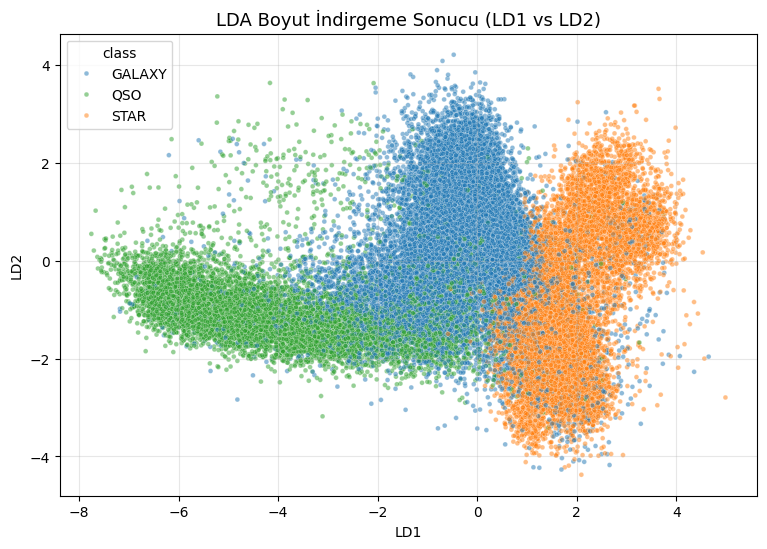

--- Sınıf Ayrılabilirliği Silhouette Skoru Karşılaştırması (10k Örneklem) ---
PCA (PC1 vs PC2) Silhouette Skoru: 0.0919
LDA (LD1 vs LD2) Silhouette Skoru: 0.4009


In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score

# 1. LDA Uygulama
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_target)

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['class'] = y_target.values

# 2. LDA Grafiği
plt.figure(figsize=(9, 6))
sns.scatterplot(x=df_lda['LD1'], y=df_lda['LD2'], hue=df_lda['class'], palette=class_palette, alpha=0.5, s=12)
plt.title('LDA Boyut İndirgeme Sonucu (LD1 vs LD2)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Bonus Metrik Hesaplama (Silhouette Score)
# Hesaplama maliyetini düşürmek için rastgele 10.000 örnek üzerinden metriği hesaplayalım
sample_indices = np.random.choice(len(X_scaled), size=10000, replace=False)

pca_score = silhouette_score(X_pca[sample_indices, :2], y_target.iloc[sample_indices])
lda_score = silhouette_score(X_lda[sample_indices], y_target.iloc[sample_indices])

print("--- Sınıf Ayrılabilirliği Silhouette Skoru Karşılaştırması (10k Örneklem) ---")
print(f"PCA (PC1 vs PC2) Silhouette Skoru: {pca_score:.4f}")
print(f"LDA (LD1 vs LD2) Silhouette Skoru: {lda_score:.4f}")

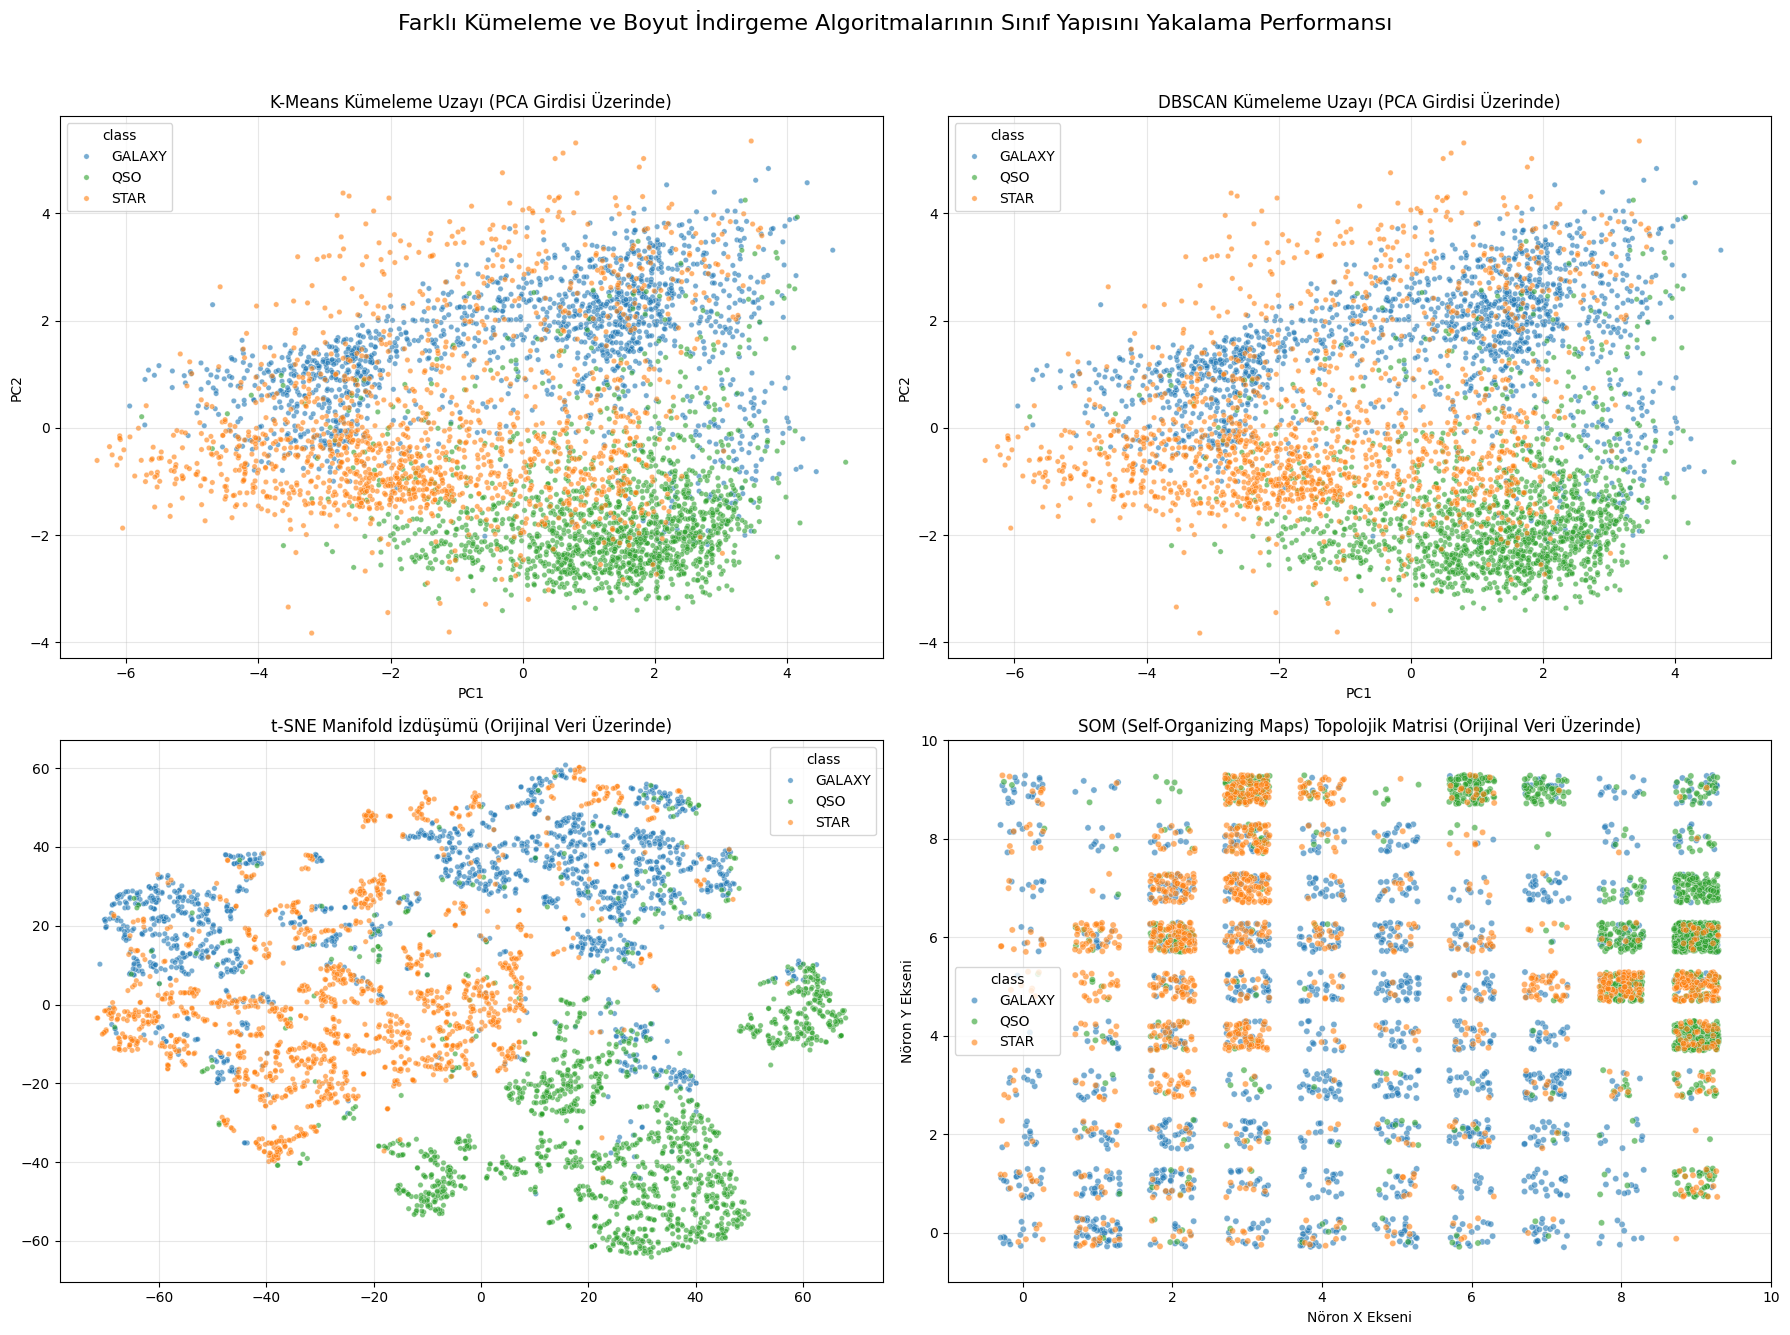

In [7]:
# Gerekli kütüphanelerin yüklenmesi (Minisom yoksa yüklemek için alt satırı aktifleştirin)
# !pip install minisom

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from minisom import MiniSom

# 1. Stratified Subsampling (Sınıf Dengeli Alt Küme Seçimi)
# Her sınıftan rastgele 1500 örnek seçerek hesaplama maliyetini düşürüyoruz
# 1. Stratified Subsampling (Sınıf Dengeli Alt Küme Seçimi) - Tüm Pandas Sürümleri İçin Uyumlu
# Her sınıftan (GALAXY, STAR, QSO) rastgele 1500 örnek seçip listeye topluyoruz
sampled_list = [df_no_outliers[df_no_outliers['class'] == c].sample(n=1500, random_state=42) for c in df_no_outliers['class'].unique()]

# Listeyi tek bir DataFrame altında birleştiriyoruz
df_sample = pd.concat(sampled_list, axis=0).reset_index(drop=True)

X_sample = df_sample.drop(columns=['class'])
y_sample = df_sample['class']

# Verilerin yeniden standardize edilmesi
scaler_sample = StandardScaler()
X_sample_scaled = scaler_sample.fit_transform(X_sample)

# 2. K-Means ve DBSCAN için PCA 2 Boyut İzdüşümü
pca_2d = PCA(n_components=2)
X_sample_pca = pca_2d.fit_transform(X_sample_scaled)

# 3. K-Means Uygulanması (Ödev isterine göre PCA verisi üzerinde)
# 3 fiziksel sınıfımız olduğu için k=3 seçiyoruz
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sample_pca)

# 4. DBSCAN Uygulanması (Ödev isterine göre PCA verisi üzerinde)
# Yoğunluk tabanlı parametreleri optimize ediyoruz
dbscan = DBSCAN(eps=0.3, min_samples=15)
dbscan_labels = dbscan.fit_predict(X_sample_pca)

# 5. t-SNE Uygulanması (Ödev isterine göre Orijinal Veri üzerinde)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample_scaled)

# 6. SOM Uygulanması (Ödev isterine göre Orijinal Veri üzerinde)
# 10x10 boyutlarında bir harita matrisi oluşturuyoruz
som_grid_x, som_grid_y = 10, 10
som = MiniSom(x=som_grid_x, y=som_grid_y, input_len=X_sample_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train_random(X_sample_scaled, num_iteration=1000)

# Her veri noktasının harita üzerindeki kazanan nöron (winning neuron) koordinatlarını bulma
som_w = np.array([som.winner(x) for x in X_sample_scaled])
# Noktaların üst üste binip tek nokta gibi görünmesini engellemek için hafif bir jitter (gürültü) ekliyoruz
som_x_jittered = som_w[:, 0] + np.random.uniform(-0.3, 0.3, len(som_w))
som_y_jittered = som_w[:, 1] + np.random.uniform(-0.3, 0.3, len(som_w))

# 7. TÜM SONUÇLARIN YAN YANA GÖRSELLEŞTİRİLMESİ (2x2 Matris)
# Ödev isterine göre tüm grafiklerde noktalar GERÇEK SINIF ETİKETLERİNE göre renklendirilmiştir.
# Böylece algoritmaların sınıfları ne kadar yakalayabildiği net görülecektir.
class_palette = {'GALAXY': '#1f77b4', 'STAR': '#ff7f0e', 'QSO': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A. K-Means Grafiği
sns.scatterplot(ax=axes[0, 0], x=X_sample_pca[:, 0], y=X_sample_pca[:, 1], hue=y_sample, palette=class_palette, alpha=0.6, s=15)
axes[0, 0].set_title('K-Means Kümeleme Uzayı (PCA Girdisi Üzerinde)', fontsize=12)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].grid(True, alpha=0.3)

# B. DBSCAN Grafiği
sns.scatterplot(ax=axes[0, 1], x=X_sample_pca[:, 0], y=X_sample_pca[:, 1], hue=y_sample, palette=class_palette, alpha=0.6, s=15)
axes[0, 1].set_title('DBSCAN Kümeleme Uzayı (PCA Girdisi Üzerinde)', fontsize=12)
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].grid(True, alpha=0.3)

# C. t-SNE Grafiği
sns.scatterplot(ax=axes[1, 0], x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, palette=class_palette, alpha=0.6, s=15)
axes[1, 0].set_title('t-SNE Manifold İzdüşümü (Orijinal Veri Üzerinde)', fontsize=12)
axes[1, 1].set_xlabel('t-SNE Boyut 1')
axes[1, 1].set_ylabel('t-SNE Boyut 2')
axes[1, 0].grid(True, alpha=0.3)

# D. SOM Grafiği
sns.scatterplot(ax=axes[1, 1], x=som_x_jittered, y=som_y_jittered, hue=y_sample, palette=class_palette, alpha=0.6, s=20)
axes[1, 1].set_title('SOM (Self-Organizing Maps) Topolojik Matrisi (Orijinal Veri Üzerinde)', fontsize=12)
axes[1, 1].set_xlabel('Nöron X Ekseni')
axes[1, 1].set_ylabel('Nöron Y Ekseni')
axes[1, 1].set_xlim(-1, som_grid_x)
axes[1, 1].set_ylim(-1, som_grid_y)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Farklı Kümeleme ve Boyut İndirgeme Algoritmalarının Sınıf Yapısını Yakalama Performansı', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

--- Örneklem Betimsel İstatistikleri (u_g_index) ---
Galaksi Örneklem Ortalaması : 1.5886
Kuasar Örneklem Ortalaması  : 0.4254
Yıldız Örneklem Ortalaması  : 1.5841

--- Test 1: Galaksi vs Kuasar T-Testi Sonuçları ---
T-İstatistiği (t-statistic) : 14.9259
p-Değeri (p-value)          : 2.2414283966099165e-38
Sonuç: p < 0.05 olduğu için H0 hipotezi REDDEDİLİR. İki popülasyon ortalaması arasında anlamlı bir fark vardır.
--------------------------------------------------
--- Test 2: Yıldız vs Kuasar T-Testi Sonuçları ---
T-İstatistiği (t-statistic) : 17.7090
p-Değeri (p-value)          : 6.960043300209118e-51
Sonuç: p < 0.05 olduğu için H0 hipotezi REDDEDİLİR. İki popülasyon ortalaması arasında anlamlı bir fark vardır.


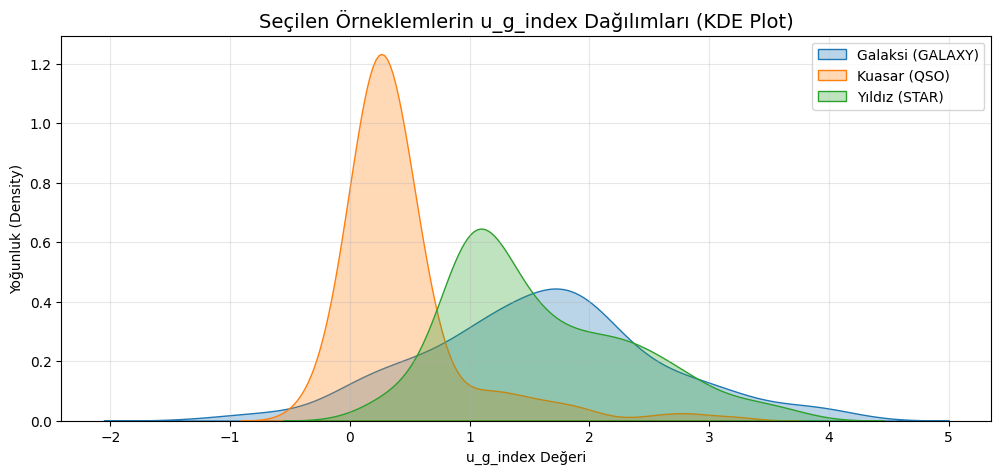

In [8]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Her Sınıftan Rastgele 200 Bağımsız Örneklem Çekilmesi
np.random.seed(42) # Sonuçların tekrarlanabilir olması için

galaxy_sample = df_no_outliers[df_no_outliers['class'] == 'GALAXY']['u_g_index'].sample(n=200, random_state=42)
qso_sample = df_no_outliers[df_no_outliers['class'] == 'QSO']['u_g_index'].sample(n=200, random_state=42)
star_sample = df_no_outliers[df_no_outliers['class'] == 'STAR']['u_g_index'].sample(n=200, random_state=42)

print("--- Örneklem Betimsel İstatistikleri (u_g_index) ---")
print(f"Galaksi Örneklem Ortalaması : {galaxy_sample.mean():.4f}")
print(f"Kuasar Örneklem Ortalaması  : {qso_sample.mean():.4f}")
print(f"Yıldız Örneklem Ortalaması  : {star_sample.mean():.4f}\n")

# 2. T-TESTİ 1: GALAKSİ vs KUASAR
# H0: Galaksiler ve Kuasarların u_g_index ortalamaları arasında istatistiksel olarak anlamlı bir fark yoktur.
# H1: Galaksiler ve Kuasarların u_g_index ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.
t_stat1, p_val1 = stats.ttest_ind(galaxy_sample, qso_sample, equal_var=False)

print("--- Test 1: Galaksi vs Kuasar T-Testi Sonuçları ---")
print(f"T-İstatistiği (t-statistic) : {t_stat1:.4f}")
print(f"p-Değeri (p-value)          : {p_val1}")
if p_val1 < 0.05:
    print("Sonuç: p < 0.05 olduğu için H0 hipotezi REDDEDİLİR. İki popülasyon ortalaması arasında anlamlı bir fark vardır.")
else:
    print("Sonuç: p >= 0.05 olduğu için H0 hipotezi REDDEDİLEMEZ. Anlamlı bir fark bulunamamıştır.")

print("-" * 50)

# 3. T-TESTİ 2: YILDIZ vs KUASAR
# H0: Yıldızlar ve Kuasarların u_g_index ortalamaları arasında istatistiksel olarak anlamlı bir fark yoktur.
# H1: Yıldızlar ve Kuasarların u_g_index ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.
t_stat2, p_val2 = stats.ttest_ind(star_sample, qso_sample, equal_var=False)

print("--- Test 2: Yıldız vs Kuasar T-Testi Sonuçları ---")
print(f"T-İstatistiği (t-statistic) : {t_stat2:.4f}")
print(f"p-Değeri (p-value)          : {p_val2}")
if p_val2 < 0.05:
    print("Sonuç: p < 0.05 olduğu için H0 hipotezi REDDEDİLİR. İki popülasyon ortalaması arasında anlamlı bir fark vardır.")
else:
    print("Sonuç: p >= 0.05 olduğu için H0 hipotezi REDDEDİLEMEZ. Anlamlı bir fark bulunamamıştır.")

# 4. Dağılım ve Güven Aralıklarının Görselleştirilmesi
plt.figure(figsize=(12, 5))
sns.kdeplot(galaxy_sample, label='Galaksi (GALAXY)', fill=True, alpha=0.3)
sns.kdeplot(qso_sample, label='Kuasar (QSO)', fill=True, alpha=0.3)
sns.kdeplot(star_sample, label='Yıldız (STAR)', fill=True, alpha=0.3)
plt.title('Seçilen Örneklemlerin u_g_index Dağılımları (KDE Plot)', fontsize=14)
plt.xlabel('u_g_index Değeri')
plt.ylabel('Yoğunluk (Density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()